## Logistic Regression

Logistic Regression is very similar to linear regression, except all of the points can only have $y$-values of $1$ or $0$. This is useful if we want to predict whether something is or isn't part of a particular class. Instead of fitting a line (as in linear regression), logistic regression involves fitting a probability curve.

For example, using our device traffic, let's see whether we can predict a DNS packet is request or response from its length. 

First, let's import the data, extract only the DNS packets, and view the first few packets.

In [1]:
# Pandas, Numpy
import numpy as np
import pandas as pd

import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

# Machine Learning
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

# Plotting
import matplotlib.pyplot as plt
%matplotlib inline

import sys
#sys.path.insert(1,"/Users/feamster/research/netml/src/")
import netml
from netml.pparser.parser import PCAP

In [2]:
hpcap = PCAP('data/http.pcap', flow_ptks_thres=2, verbose=10)

hpcap.pcap2pandas()
pcap = hpcap.df

Each row in the printed data is a packet and each column is a feature of the packet.

Next let's divide the DNS packets into requests and repsonses, and convert them into points where the $x$-value is the length of the packet and $y$-value is $0$ for requests and $1$ for responses. This will allow us to fit the data to a logistic regression curve.

In [5]:
SERVER_PORTS = {80, 443, 8080, 8443}

requests  = pcap[pcap['port_dst'].isin(SERVER_PORTS)]   # client -> server
responses = pcap[pcap['port_src'].isin(SERVER_PORTS)]   # server -> client


In [6]:
X = np.concatenate([requests['length'].values,
                    responses['length'].values]).reshape(-1, 1)

y = np.concatenate([np.zeros(len(requests)),    # 0 = request
                    np.ones(len(responses))])   # 1 = response

print(X.shape, y.shape)   # (24516, 1) (24516,)

(24516, 1) (24516,)


Let's see how many data points we have.

Text(0.5, 0, 'packet length (bytes)')

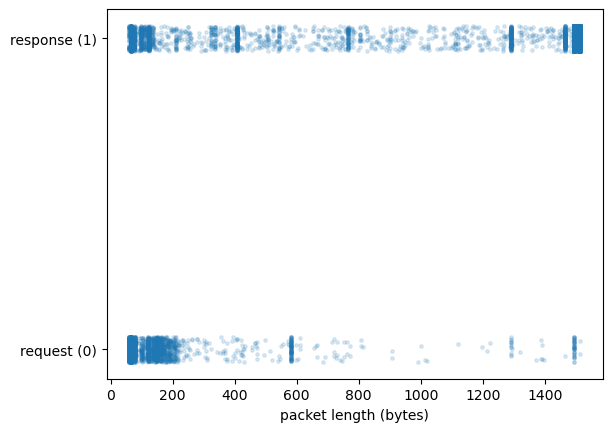

In [7]:
plt.scatter(X, y + np.random.uniform(-0.04, 0.04, len(y)), s=6, alpha=0.15)
plt.yticks([0, 1], ['request (0)', 'response (1)'])
plt.xlabel('packet length (bytes)')

24,516 data points — 3,697 requests (y=0) and 20,819 responses (y=1).

Next we will convert the DNS response column into a 0/1 value so that it is amenable to logstic regression.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, balanced_accuracy_score)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3,
                                      random_state=42, stratify=y)

clf = make_pipeline(StandardScaler(),
                    LogisticRegression(class_weight='balanced', max_iter=1000))
clf.fit(Xtr, ytr)

yp = clf.predict(Xte)
proba = clf.predict_proba(Xte)[:, 1]

print("accuracy         ", clf.score(Xte, yte))
print("balanced accuracy", balanced_accuracy_score(yte, yp))
print("ROC AUC          ", roc_auc_score(yte, proba))
print(confusion_matrix(yte, yp))
print(classification_report(yte, yp, target_names=['request', 'response'], digits=3))

accuracy          0.9225016995241332
balanced accuracy 0.9473254948090133
ROC AUC           0.9631759276342631
[[1090   19]
 [ 551 5695]]
              precision    recall  f1-score   support

     request      0.664     0.983     0.793      1109
    response      0.997     0.912     0.952      6246

    accuracy                          0.923      7355
   macro avg      0.830     0.947     0.873      7355
weighted avg      0.947     0.923     0.928      7355

